#  Impact of AOCS jitter on the photometry at camera level

#### Goals

Test the impact and behavior of spacecraft Attitude and Orbital Control System (AOCS) jitter on camera level. 

#### Context

In order to achieve the required noise budget at mission level, the PMC has defined Mean Pointing Error and Relative Pointing Error requirements at camera level. In the high frequency range ($f \gg 0.04$Hz), the dominant contribution results from the performance of the attitude and orbit control system of the S/C (jitter).

#### Simulations

To test the impact of jitter it should be enough to have several short-term simulations (1 day long), for 24 N-CAMs and several quarters. Specifically one simulation with fast jitter (8 Hz), and one simulation without jitter (only white noise jitter) shall be compared to tell whether a jitter correction on-ground is mandatory or not. 
Prime have delivered a high frequency jitter simulations for one N-Cam w.r.t. to F2-Cam with a cadence of 8 Hz and duration of 27h. We shall investigate if this simulation can be cycled to the remaining cameras and how this might impact the forthcoming analysis.

#### Data analysis

The analysis is shown at the very end of this notebook.

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
import os
import sys
import h5py
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from scipy.ndimage import median_filter
from zipfile import ZipFile

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

import warnings 
warnings.filterwarnings("ignore")

---
## 1 - Pointing errors 
---

The Prime is delivering the coefficients of the rotations matrices transforming the pointing directions in the
PLM (payload module) reference frame, so-called **Quarternions**.

### 1.1 - Prime 2021-09-20: AOCS + TED in CM LOS

Each LOS variable has a sample rate of 8Hz and is in radians. The periods where reaction wheel offloading were simulated, including a tranquilisation time after the transition from OLM back to GAM are set to `NaN`.

In [21]:
# Shorten time series and create time points
tdur       = 27       # [h]
dt         = 0.125    # [s] 8 Hz
rad2arcsec = 206265   # Conversion

# Load Prime 
path  = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2021sep"
f = h5py.File(f"{path}/CM_LOS_Combined_v2.mat", "r")

In [22]:
# Line of sight (LOS) of way, pitch, and roll [arcsec]
x = f['LOSX'][0] * rad2arcsec 
y = f['LOSY'][0] * rad2arcsec 
z = f['LOSZ'][0] * rad2arcsec

In [23]:
# Create data frame
data = np.array([x,y,z]).T
df = pd.DataFrame(data, columns=["yaw", "pitch", "roll"])

In [24]:
# Remove NaNs
df = df.dropna(how='all')

In [25]:
df -= df.mean() 

In [27]:
t = np.arange(0, df.yaw.shape[0]*dt, dt, dtype="float32")
df["time"] = t

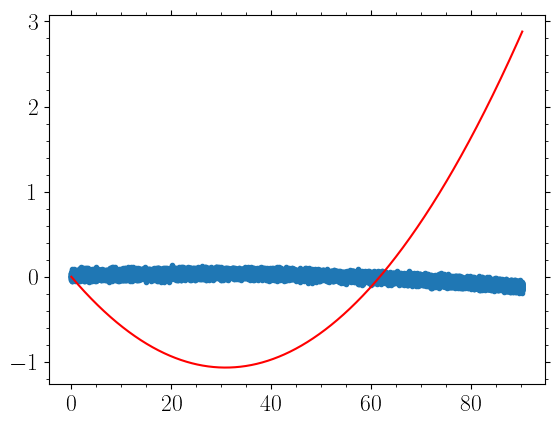

In [144]:
# poly = np.polyfit(df['time'], df['yaw'], deg=2)
poly = np.array([+15.0e-14,  -8e-07,  0])
df['poly'] = np.polyval(poly, df['time'])
plt.plot(df.time.iloc[::1000]/86400, df.yaw.iloc[::1000], '.')
plt.plot(df.time.iloc[::1000]/86400, df.poly.iloc[::1000], 'r-')

In [308]:
# Save jitter file
np.savetxt(f'{os.getcwd()}/AOCS_Prime_2021sep_27h_8Hz.txt', data, delimiter=' ',
          fmt=['%.3f', '%.9f', '%.9f', '%.9f'])

<IPython.core.display.Javascript object>


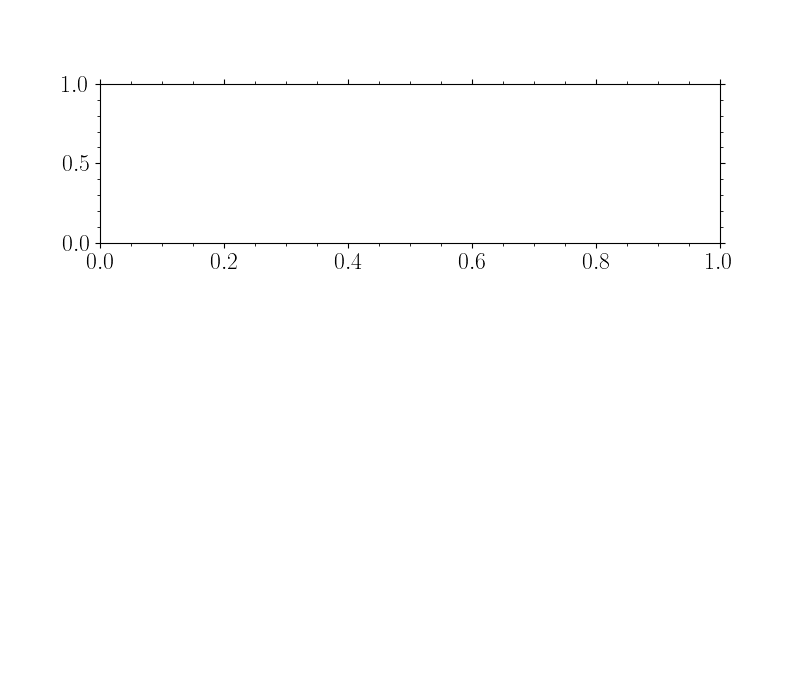

ValueError: x and y must have same first dimension, but have shapes (501833607,) and (62373878,)

In [314]:
# Plot
fig, ax = pt.plotYawPitchRollTimeSeries(t/3600., signals.T, units=["hours", "arcsec"], title='AOCS time series', 
                                        figsize=(8,7));
fig.savefig('aocs_jitter_time_series.png', bbox_inches='tight', dpi=200)

In [310]:
# Determine PSD of yaw
f, psd = periodogram(x, 8, scaling='density')
f   *= 1e6  # [muHz]
psd *= 1e6  # [arcsec^2/muHz]
psd_med = median_filter(psd, 100)

In [ ]:
# Plot PSD
plt.figure(figsize=(8,4))
plt.plot(f, psd)
plt.plot(f, psd_med, 'r-')
plt.xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
plt.ylabel(r"PSD [arcsec$^2$ $\mu$Hz$^{-1}$]")
plt.xlim(1e2, f.max())
plt.ylim(1e-11, 1e6)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout();

### 1.2 - AOCS jitter time series from Prime 2020 January

We use the $8\,\rm Hz$ AOCS jitter time series simulated delivered by the ESA Prime contractor the 2021-01-09. See the technidal note: *Description of pointing data delivery as part of System PDR* (`PTO-OHB-SYS-MEM-0222 i.1.0`). This dataset consist of several simulations of which the first called `PLATO_PDR_FPM_02_longrun_APE`. 

In [ ]:
path = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2020jan"
df = pd.read_csv(f'{path}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])
df.head()

In [ ]:
# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

In [ ]:
# Plot jitter time series]
pt.plotYawPitchRollTimeSeries(df["t"].to_numpy()/3600., df.to_numpy()[:,1:].T, 
                              title='AOCS time series', figsize=(8,7));

In [ ]:
# Determine PSD of yaw
f, psd = periodogram(df["x"], 8, scaling='density')
f   *= 1e6  # [muHz]
psd *= 1e6  # [ppm^2/muHz]
psd_med = median_filter(psd, 100)

In [ ]:
# Plot PSD of yaw
plt.figure(figsize=(8,4))
plt.plot(f, psd)
plt.plot(f, psd_med, 'r-')
plt.xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
plt.ylabel(r"PSD [arcsec$^2$ $\mu$Hz$^{-1}$]")
plt.xlim(1e2, f.max())
plt.ylim(1e-7, 1e6)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout();

In [ ]:
# Split time from signals to adapt to plots below
data = df.to_numpy()
time    = data[:,0]
signals = data[:,1:]

# Save jitter file
np.savetxt(f'AOCS_Prime_2020jan_28h_8Hz.txt', data, delimiter=' ',
          fmt=['%.3f', '%.9f', '%.9f', '%.9f'])

### 1.3 - Pointing Reproducibility Error (PRE)

In [ ]:
# data = rf.getPointingRepeatabilityError(ra, dec, kappa, sigma=3, quarter=[1, 8], outdir=None, show_table=False)

### 1.4 - Camera alignment errors in yaw, pitch, and roll (x, y, z)

In [ ]:
# APE = rf.cameraAlignmentErrors(ra, dec, kappa, sigma=3, outdir=None, show_table=False)

---
## 2 - Data Analysis: Indiviual N-CAM LCs
---

In [4]:
# User parameters
numStar = 400
simDir = "/lhome/nicholas/data/sims_kul21"
inputDirNone  = simDir + "/jitterNone"
inputDirRed   = simDir + "/jitterRed"
inputDirPrime = simDir + "/jitterPrime"
outputFileNone  = os.getcwd() + "/resultsJitterNone.ftr"
outputFileRed   = os.getcwd() + "/resultsJitterRed.ftr"
outputFilePrime = os.getcwd() + "/resultsJitterPrime.ftr"

### Correct all feather files

In [ ]:
# outputDirNone  = simDir + "/corrected_jitterNone"
# outputDirRed   = simDir + "/corrected_jitterRed"
# outputDirPrime = simDir + "/corrected_jitterPrime"

In [ ]:
# phot = LightCurve(inputDirNone, mode="multi")
# phot.correct_and_save(inputDirNone, outputDirNone, numStar)

In [ ]:
# phot = LightCurve(inputDirRed, mode="multi")
# phot.correct_and_save(inputDirRed, outputDirRed, numStar)

In [ ]:
# phot = LightCurve(inputDirPrime, mode="multi")
# phot.correct_and_save(inputDirPrime, outputDirPrime, numStar)

### Test example

In [6]:
inputDirNone = f"{simDir}/jitterNone/000000001"
phot = LightCurve(inputDirNone, mode="multi")
phot.unpack()
filenames = phot.files("ftr")
filenames[0]

'/lhome/nicholas/data/sims_kul21/jitterNone/000000001/000000001_Ncam1.1_Q1.ftr'

In [7]:
lc = LightCurve(filenames[0])
lc.data().head()

,index,time,flux,cx,cy,bg,flux_err,cx_err,cy_err,bg_err,chi2,iter,lamb
0,0,0.0,606075.746123,3.230747,2.768652,2009.755255,814.503612,0.000797,0.000723,13.045489,193.171266,5,10000.000000
1,1,25.0,606785.542829,3.229333,2.767705,1987.570085,814.915023,0.000797,0.000722,13.018048,190.163315,6,0.000137
2,2,50.0,605527.045195,3.231048,2.767833,1973.263711,813.835064,0.000798,0.000723,12.987917,188.518903,6,0.000137
3,3,75.0,606168.760637,3.230944,2.767467,1981.502391,814.524772,0.000797,0.000722,13.011006,184.034287,6,0.000137
4,4,100.0,606534.281295,3.231030,2.766942,2014.118327,814.779747,0.000800,0.000722,13.047251,189.652050,6,0.000137


In [9]:
# Get target star information
star = lc.star_info(phot.files("cat")[0])
print(f"""
Pmag : {star[0]}
rOA  : {star[1]}
rCOB : {star[2]}
nCon : {star[3]}
rCon : {star[4]}
dMag : {star[5]}
SPR  : {star[6]}
""")


Pmag : 9.64
rOA  : 0.8748219326127598
rCOB : 0.3934810992831747
nCon : 1
rCon : 1.53480159802395
dMag : 3.719999999999999
SPR  : 0.15987717345277994



In [38]:
lc.getNSR()

110.93387901295074

<IPython.core.display.Javascript object>


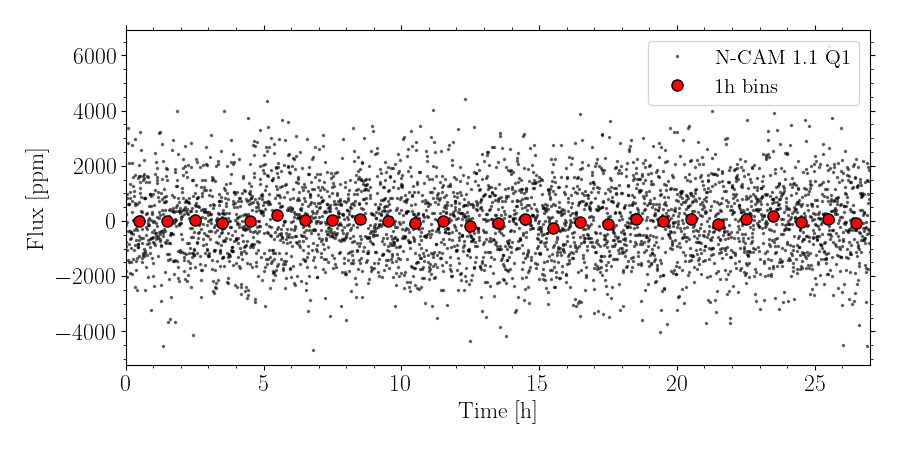

In [41]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(9,4.5));
# fig.savefig('camera_JitterNone_Star1.png', bbox_inches='tight', dpi=200)

### No jitter

In [ ]:
# phot = LightCurve(inputDirNone, mode="multi")
# phot.analyse_single_camera(inputDirNone, outputFileNone, numStar)

In [ ]:
# Load results and sort logically
df1 = pd.read_feather(outputFileNone)
df1 = df1.loc[df1["flag"] == 0]
df1_tar = df1.loc[df1["ncon"] == 0]
df1_con = df1.loc[df1["ncon"] > 0]
df1_c = df1.loc[(df1["ncon"] > 0) & (df1["rcon"] < 2)]
df1

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_c, column="dmag", figsize=(8,6))
ax.set_title("No Jitter: Individual N-CAM");

# Plot one of the outliers
# star = df1.loc[df1["star"] == 316]
# ax.scatter(star["mag"], star["NSR"], s=50, facecolors='none', edgecolors='r');
# fig.savefig('camera_JitterNone_NSR.png', bbox_inches='tight', dpi=200)

fig.savefig('camera_JitterNone_con_dmag.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_c, column="rcon", figsize=(8,6))
ax.set_title("No Jitter: Individual N-CAM");

# Plot one of the outliers
# star = df1.loc[df1["star"] == 316]
# ax.scatter(star["mag"], star["NSR"], s=50, facecolors='none', edgecolors='r');
# fig.savefig('camera_JitterNone_NSR.png', bbox_inches='tight', dpi=200)

fig.savefig('camera_JitterNone_con_dpix.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_tar, column="rOA")
ax.set_title("No Jitter: Individual N-CAM and no stellar contaminants");

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_tar, column="quarter")
ax.set_title("No Jitter: Individual N-CAM and no stellar contaminants");

### Red Noise

In [ ]:
# phot = LightCurve(inputDirRed, mode="multi")
# phot.analyse_single_camera(inputDirRed, outputFileRed, numStar)

In [ ]:
# Load results and sort logically
df2 = pd.read_feather(outputFileRed)
df2 = df2.loc[df2["flag"] == 0]
df2_tar = df2.loc[df2["ncon"] == 0]
df2_con = df2.loc[df2["ncon"] > 0]
df2_c = df2.loc[(df2["ncon"] > 0) & (df2["rcon"] < 2)]
df2.head()

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2_c, column="dmag")
ax.set_title("Red Noise: Individual N-CAM");

### Prime Jitter

In [ ]:
# phot = LightCurve(inputDirPrime, mode="multi")
# phot.analyse_single_camera(inputDirPrime, outputFilePrime, numStar)

In [ ]:
# Load results and sort logically
df3 = pd.read_feather(outputFilePrime)
df3 = df3.loc[df3["flag"] == 0]
df3_tar = df3.loc[df3["ncon"] == 0]
df3_con = df3.loc[df3["ncon"] > 0]
df3_c = df3.loc[(df3["ncon"] > 0) & (df3["rcon"] < 2)]
df3.head()

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df3_c, column="SPR")
ax.set_title("Prime Jitter: Individual N-CAM");

### Remove outliers

In [ ]:
# Remove outlier from data 
SPR_lim = 0.1
df1_outlier = df1.loc[(df1["ncon"] > 0) & (df1["SPR"] > SPR_lim)]
df2_outlier = df2.loc[(df2["ncon"] > 0) & (df2["SPR"] > SPR_lim)]
df3_outlier = df3.loc[(df3["ncon"] > 0) & (df3["SPR"] > SPR_lim)]
df1_inlier = df1.drop(df1_outlier["index"])
df2_inlier = df2.drop(df2_outlier["index"])
df3_inlier = df3.drop(df3_outlier["index"])

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_inlier, column="ncon")
ax.set_title("Prime Jitter: Individual N-CAM");

In [ ]:
# Find n worst outliers
n = 10
df1_outlier["NSR"].argsort()[-n:][::-1]

In [ ]:
df1_outlier.iloc[4234]

### Residuals

In [ ]:
# Residuals for all stars
df21 = df1.copy()
df31 = df2.copy()
df23 = df3.copy()
df21["res"] = df2["NSR"] - df1["NSR"]
df31["res"] = df3["NSR"] - df1["NSR"]
df23["res"] = df2["NSR"] - df3["NSR"]

# Residuals for single stars
df21_tar = df1_tar.copy()
df31_tar = df2_tar.copy()
df23_tar = df3_tar.copy()
df21_tar["res"] = df2_tar["NSR"] - df1_tar["NSR"]
df31_tar["res"] = df3_tar["NSR"] - df1_tar["NSR"]
df23_tar["res"] = df2_tar["NSR"] - df3_tar["NSR"]

# Residual for inliers
df21_inlier = df1_inlier.copy()
df31_inlier = df2_inlier.copy()
df23_inlier = df3_inlier.copy()
df21_inlier["res"] = df2_inlier["NSR"] - df1_inlier["NSR"]
df31_inlier["res"] = df3_inlier["NSR"] - df1_inlier["NSR"]
df23_inlier["res"] = df2_inlier["NSR"] - df3_inlier["NSR"]

### Residuals for all

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df21_tar, column="ferr", residuals="camera", figsize=(8,6))
ax.set_title(r"Residuals $|\rm {NSR}_{red} - {NSR}_{none}|$", pad=10);
fig.savefig('camera_Residuals_Red-None_inlier.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df31_tar, column="ferr", residuals="camera", figsize=(8,6))
ax.set_title(r"Residuals $|\rm {NSR}_{prime} - {NSR}_{none}|$", pad=10);
fig.savefig('camera_Residuals_Prime-None_inlier.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df23_tar, column="ferr", residuals="camera")
ax.set_title(r"Residuals $|\rm {NSR}_{prime} - {NSR}_{red}|$", pad=10);

### Residuals for Inliers

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df21_tar, column="ferr", residuals="camera", yscale="linear")
ax.set_title(r"Residuals $(\rm {NSR}_{red} - {NSR}_{none})$", pad=10);

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df31_tar, column="ferr", residuals="camera", yscale="linear")
ax.set_title(r"Inliers $(\rm {NSR}_{prime} - {NSR}_{none})$", pad=10);

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df31_tar, column="quarter", residuals="camera", yscale="log")
ax.set_title(r"Inliers $(\rm {NSR}_{prime} - {NSR}_{none})$", pad=10);

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df23_tar, column="rOA", residuals="camera", yscale="linear")
ax.set_title(r"Residuals $(\rm {NSR}_{red} - {NSR}_{prime})$", pad=10);
fig.savefig('camera_Residuals_Red-Prime_inlier.png', bbox_inches='tight', dpi=200)

---

## 3 - Data Analysis: Merged N-CAM LCs

---

In [272]:
# User parameters
numStar = 400
simDir = "/lhome/nicholas/sims_kul21"
inputDirNone  = simDir + "/jitterNone"
inputDirRed   = simDir + "/jitterRed"
inputDirPrime = simDir + "/jitterPrime"
outputFileNoneMerged  = os.getcwd() + "/resultsJitterNoneMerged.ftr"
outputFileRedMerged   = os.getcwd() + "/resultsJitterRedMerged.ftr"
outputFilePrimeMerged = os.getcwd() + "/resultsJitterPrimeMerged.ftr"

### Test example

<IPython.core.display.Javascript object>


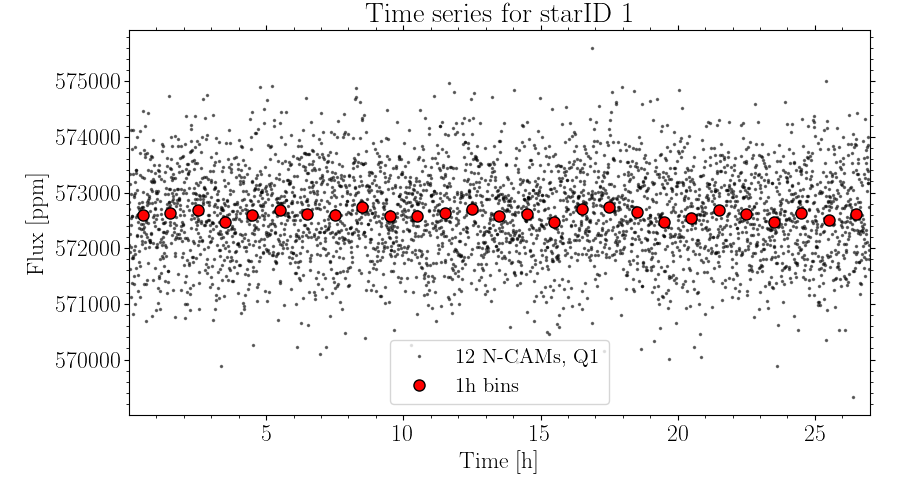

In [276]:
phot = LightCurve(inputDirNone+"/000000001/", mode="multi")
phot.unpack()

lc.getNSR(influx="ppm")

fig, ax = lc.plot(time_unit="h", binsize=1, cameras=12, quarter=1)
ax.set_title("Time series for starID 1");
fig.savefig('camera_TimeSeries_star1.png', bbox_inches='tight', dpi=200)

phot.remove()

### No Jitter

In [ ]:
# phot = LightCurve(inputDirNone, mode="multi")
# phot.merge_cameras(outputFileNoneMerged, numStar)

In [277]:
# Load results and sort logically
df1 = pd.read_feather(outputFileNoneMerged)
df1_tar = df1.loc[df1["ncon"] == 0]
df1.head()

,index,star,mag,rOA,quarter,ncam,ncon,SPR,NSR,flux_err,flag
0,0,1,9.64,12.722017,1,12,1,0.158036,32.761650,516.225525,0.0
1,1,1,9.64,12.722017,2,6,1,0.158036,47.075985,517.470337,0.0
2,2,1,9.64,12.722017,3,11,1,0.158036,33.800575,508.133789,0.0
3,3,1,9.64,12.722017,4,6,1,0.158036,46.278606,515.485413,0.0
4,4,1,9.64,12.722017,5,11,1,0.158036,34.048370,508.980774,0.0


<IPython.core.display.Javascript object>


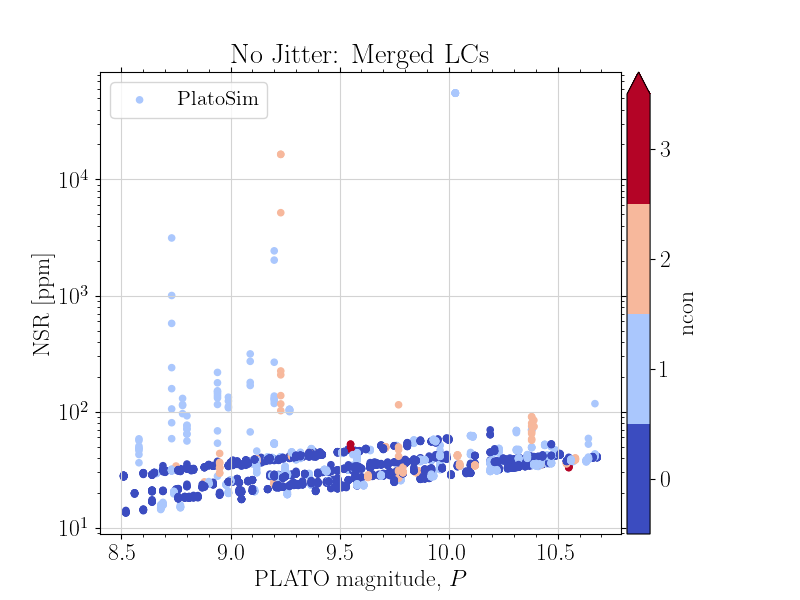

In [278]:
# Fetch only the first star and the first quarter
fig, ax = pt.plotNSRvsMagnitude(df1, column="ncon", figsize=(8,6))
ax.set_title("No Jitter: Merged LCs");

<IPython.core.display.Javascript object>


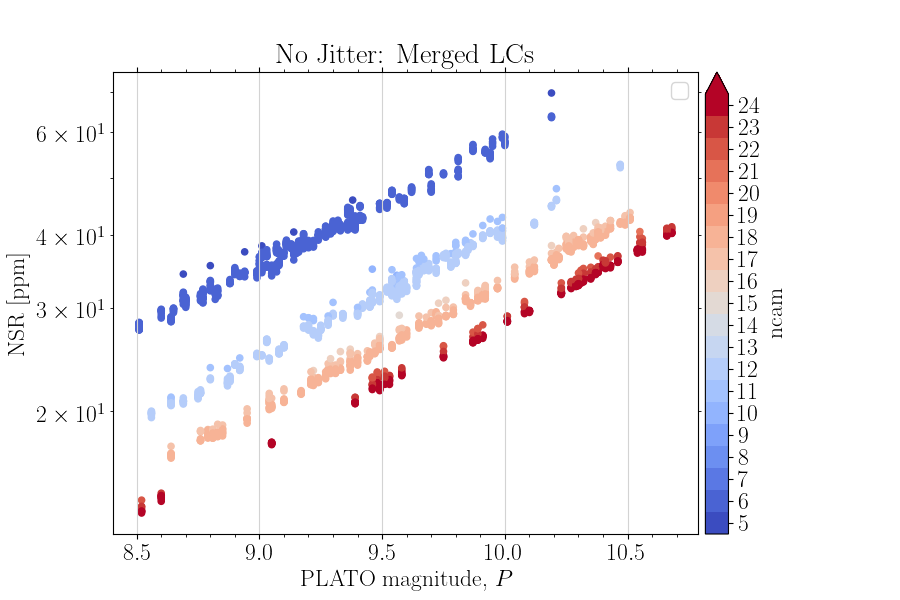

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [292]:
# # Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_tar, column="ncam", figsize=(9,6))
ax.set_title("No Jitter: Merged LCs");

---
### Red Noise
---

In [293]:
# phot = LightCurve(inputDirRed, mode="multi")
# phot.merge_cameras(outputFileRedMerged, numStar)

In [294]:
# Load results and sort logically
df2 = pd.read_feather(outputFileRedMerged)
df2_tar = df2.loc[df2["ncon"] == 0]
df2.head()

,index,star,mag,rOA,quarter,ncam,ncon,SPR,NSR,flux_err,flag
0,0,1,9.64,12.928117,1,17,1,0.156194,27.512461,515.450500,0.0
1,1,1,9.64,12.928117,2,6,1,0.156194,47.168289,518.454773,0.0
2,2,1,9.64,12.928117,3,18,1,0.156194,27.068834,515.822021,0.0
3,3,1,9.64,12.928117,4,6,1,0.156194,46.532719,516.264893,0.0
4,4,1,9.64,12.928117,5,18,1,0.156194,26.841160,517.940857,0.0


<IPython.core.display.Javascript object>


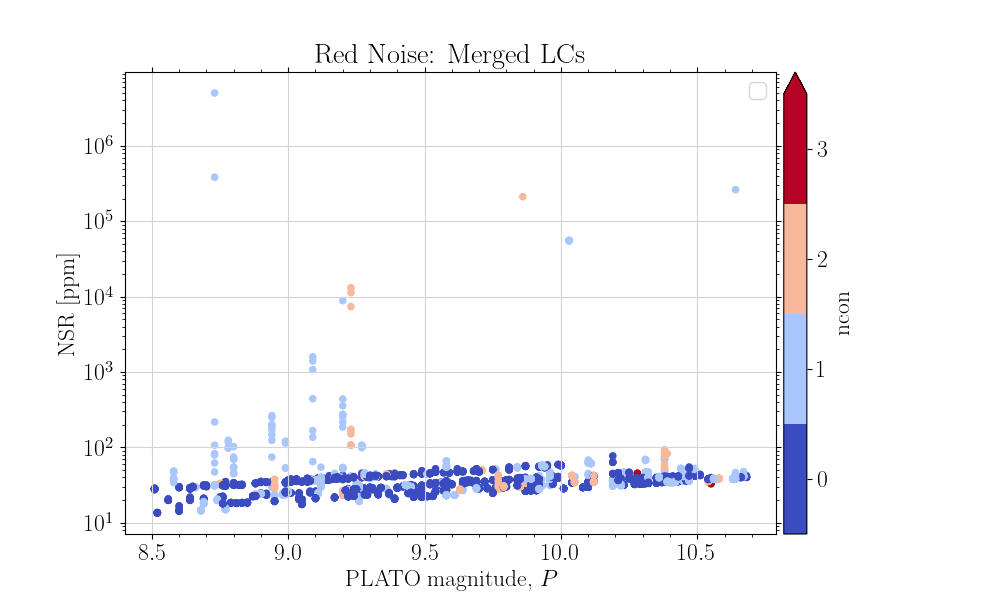

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [295]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2, column="ncon")
ax.set_title("Red Noise: Merged LCs");

<IPython.core.display.Javascript object>


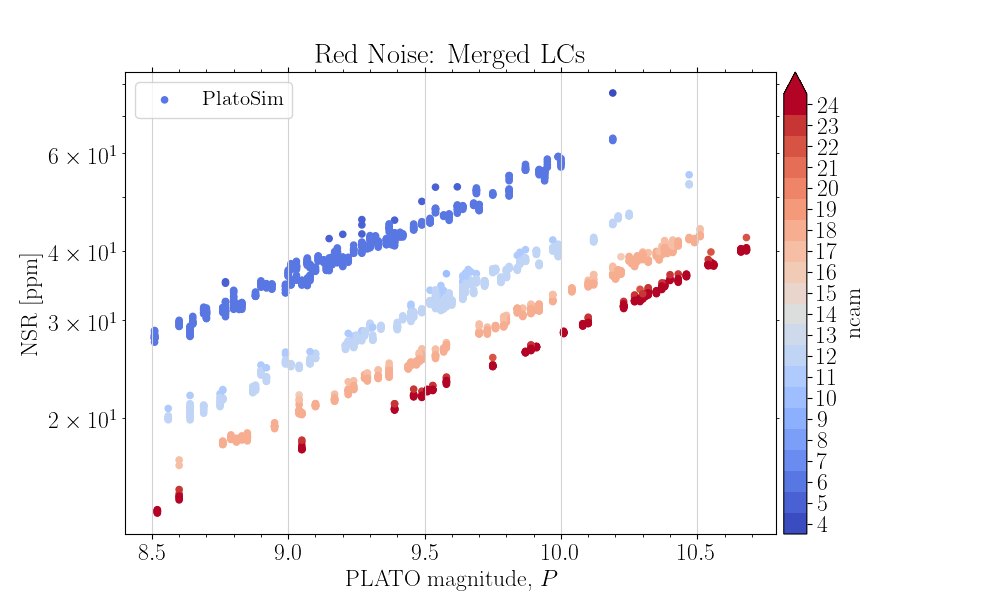

In [297]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2_nocon, column="ncam")
ax.set_title("Red Noise: Merged LCs");

---
### Prime Jitter
---

In [298]:
# phot = LightCurve(inputDirPrime, mode="multi")
# phot.merge_cameras(outputFilePrimeMerged, numStar)

In [299]:
# Load results and sort logically
df3 = pd.read_feather(outputFilePrimeMerged)
df3_tar = df3.loc[df3["ncon"] == 0]
df3.head()

,index,star,mag,rOA,quarter,ncam,ncon,SPR,NSR,flux_err,flag
0,0,1,9.64,12.928107,1,17,1,0.156194,27.398323,514.820801,0.0
1,1,1,9.64,12.928107,2,6,1,0.156194,47.316532,521.660217,0.0
2,2,1,9.64,12.928107,3,18,1,0.156194,26.957983,512.033386,0.0
3,3,1,9.64,12.928107,4,6,1,0.156194,45.958900,511.705231,0.0
4,4,1,9.64,12.928107,5,18,1,0.156194,26.644508,513.687805,0.0


<IPython.core.display.Javascript object>


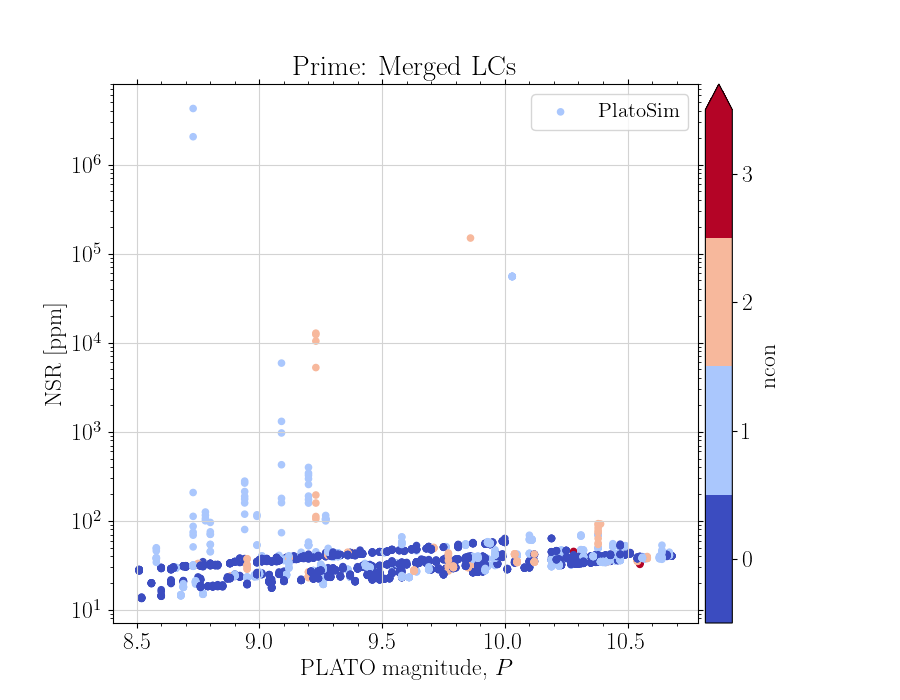

In [300]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df3, column="ncon", figsize=(9,7))
ax.set_title("Prime: Merged LCs");
fig.savefig('camera_NSR_Prime_ncon.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


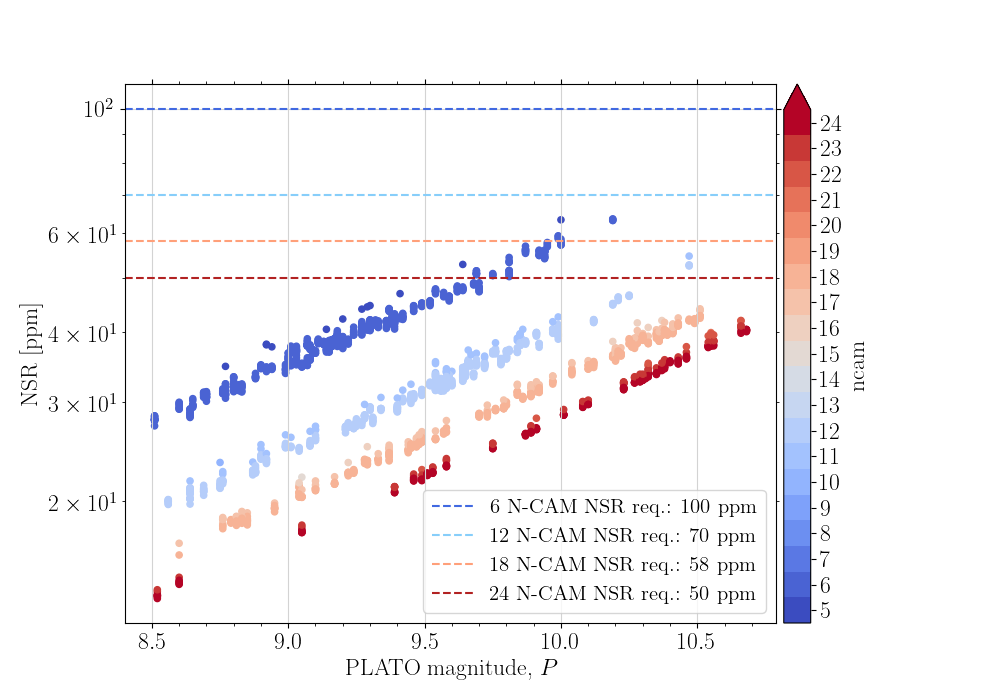

In [304]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df3_tar, column="ncam", residuals="multi", figsize=(10,7))
# ax.set_title("Merged LCs: Prime");
fig.savefig('NSRvsP.pdf', bbox_inches='tight', dpi=200)

---
### Resdiuals
---

In [ ]:
SPR_lim = 0.14
df1_outlier = df1.loc[(df1["ncon"] > 0) & (df1["SPR"] > SPR_lim)]
df2_outlier = df2.loc[(df2["ncon"] > 0) & (df2["SPR"] > SPR_lim)]
df3_outlier = df3.loc[(df3["ncon"] > 0) & (df3["SPR"] > SPR_lim)]
df1_inlier = df1.drop(df1_outlier["index"])
df2_inlier = df2.drop(df2_outlier["index"])
df3_inlier = df3.drop(df3_outlier["index"])
df1_inlier

In [ ]:
# Residuals for all stars
df21 = df1.copy()
df31 = df2.copy()
df23 = df3.copy()
df21["res"] = df2["NSR"] - df1["NSR"]
df31["res"] = df3["NSR"] - df1["NSR"]
df23["res"] = df2["NSR"] - df3["NSR"]

# Residuals for single stars
df21_tar = df1_tar.copy()
df31_tar = df2_tar.copy()
df23_tar = df3_tar.copy()
df21_tar["res"] = df2_tar["NSR"] - df1_tar["NSR"]
df31_tar["res"] = df3_tar["NSR"] - df1_tar["NSR"]
df23_tar["res"] = df2_tar["NSR"] - df3_tar["NSR"]

# Residual for inliers
df21_inlier = df1_inlier.copy()
df31_inlier = df2_inlier.copy()
df23_inlier = df3_inlier.copy()
df21_inlier["res"] = df2_inlier["NSR"] - df1_inlier["NSR"]
df31_inlier["res"] = df3_inlier["NSR"] - df1_inlier["NSR"]
df23_inlier["res"] = df2_inlier["NSR"] - df3_inlier["NSR"]
df21_tar

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df21_tar, column="ncam", residuals="system", figsize=(8,6))
ax.set_title(r"Merged LCs $|\rm {NSR}_{red} - {NSR}_{none}|$");
fig.savefig('camera_Residuals_Merged_Red-None_ncam.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df31_inlier, column="ncam", residuals="system", figsize=(8,6))
ax.set_title(r"Merged LCs $|\rm {NSR}_{prime} - {NSR}_{none}|$");
fig.savefig('camera_Residuals_Merged_Prime-None_ncam.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df23_inlier, column="ncam", residuals="system", yscale="log")
ax.set_title(r"Residuals $|\rm {NSR}_{red} - {NSR}_{prime}|$");
fig.savefig('camera_Residuals_Merged_Red-Prime_ncam.png', bbox_inches='tight', dpi=200)